In [1]:
import os
import random
import warnings

warnings.filterwarnings("ignore")


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    robust_scale,
    OneHotEncoder,
    LabelEncoder,
    TargetEncoder,
)


# import tensorflow as tf
# import keras

from keras.models import Sequential
from keras.layers import Input, Dense

print(f"NumPy version:        {np.__version__}")
print(f"Pandas version:       {pd.__version__}")
print(f"Scikit-Learn version: {__import__('sklearn').__version__}")


NumPy version:        2.4.3
Pandas version:       3.0.1
Scikit-Learn version: 1.8.0


In [3]:
data = pd.read_csv(
    "C:/Users/faiz/Desktop/Projectss/nlp-engineering/data/salary_dataset.csv"
)

# What type is this?
print(f"Type: {type(data)}")
print(f"Shape: {data.shape}  →  {data.shape[0]} rows, {data.shape[1]} columns")

Type: <class 'pandas.DataFrame'>
Shape: (30, 2)  →  30 rows, 2 columns


In [4]:
data.head(3)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0


In [5]:
# Last 3 rows
data.tail(3)


,YearsExperience,Salary
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [6]:
# Random sample - good for spotting patterns
data.sample(3)


,YearsExperience,Salary
0,1.1,39343.0
6,3.0,60150.0
15,4.9,67938.0


In [7]:
# Column names
print(f"Columns: {list(data.columns)}")


Columns: ['YearsExperience', 'Salary']


In [8]:
# Statistical summary - the most important EDA command
data.describe().T


,count,mean,std,min,25%,50%,75%,max
YearsExperience,30.0,5.313333,2.837888,1.1,3.20,4.7,7.70,10.5
Salary,30.0,76003.000000,27414.429785,37731.0,56720.75,65237.0,100544.75,122391.0


In [9]:
# Prepare features (X) and target (y)
X = data[["YearsExperience"]].values
y = data["Salary"].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (30, 1)
y shape: (30,)


In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 24 samples
Test set: 6 samples


In [11]:
# Scale features - IMPORTANT for neural networks
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print("\nScaled data ready for neural network!")



Scaled data ready for neural network!


In [14]:
# Build the neural network model
model = Sequential(
    [
        Input(shape=(1,)),  # Input: 1 feature (YearsExperience)
        Dense(64, activation="relu"),  # Hidden layer 1
        Dense(32, activation="relu"),  # Hidden layer 2
        Dense(1),  # Output layer: 1 neuron for regression
    ]
)


In [15]:
# Compile the model
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the model
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=0,
)


In [17]:
# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"\nTest Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")



Test Loss (MSE): 0.0733
Test MAE: 0.2213


In [18]:
# Make predictions
y_pred_scaled = model.predict(X_test_scaled, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()


In [19]:
# Compare predictions vs actual
comparison = pd.DataFrame(
    {"Actual": y_test, "Predicted": y_pred, "Difference": y_test - y_pred}
)
print("\nPrediction Comparison:")
print(comparison.head(10))



Prediction Comparison:
     Actual      Predicted    Difference
0  112635.0  115996.460938  -3361.460938
1   67938.0   66200.039062   1737.960938
2  113812.0  104216.093750   9595.906250
3   83088.0   72679.945312  10408.054688
4   64445.0   53449.140625  10995.859375
5   57189.0   56584.640625    604.359375


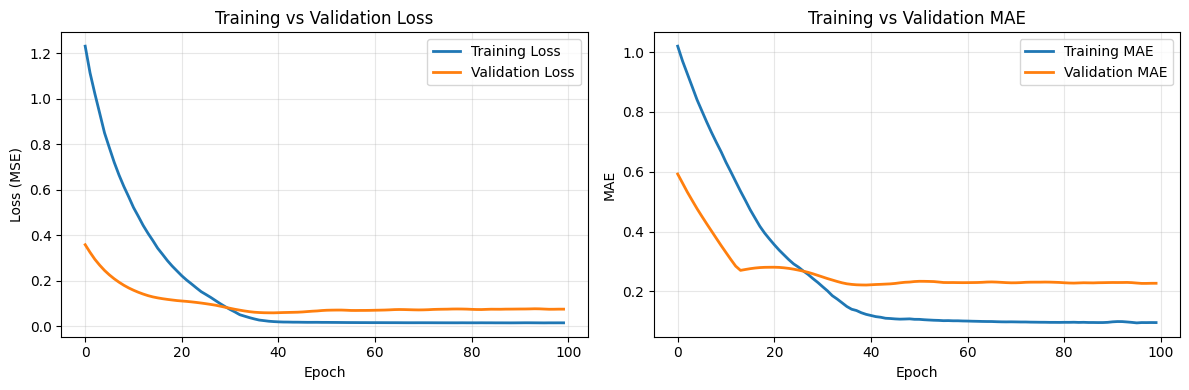

In [20]:
# Plot training history - Loss and MAE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(history.history["loss"], label="Training Loss", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history["mae"], label="Training MAE", linewidth=2)
axes[1].plot(history.history["val_mae"], label="Validation MAE", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].set_title("Training vs Validation MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


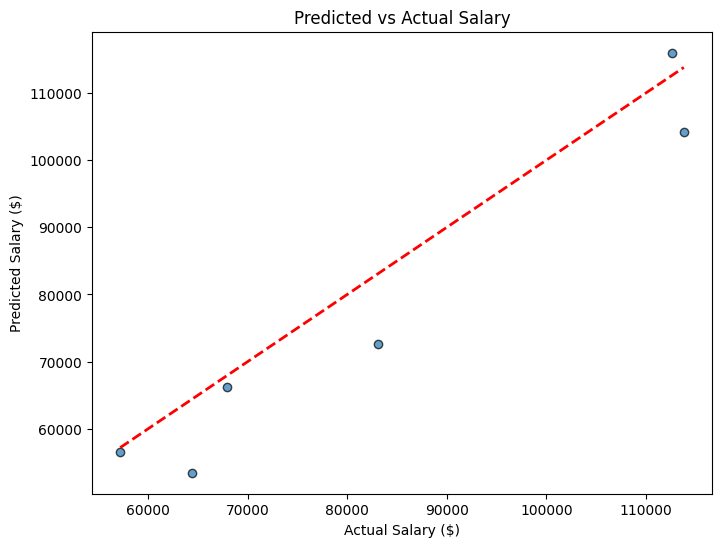

In [21]:
# Plot predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Salary ($)")
plt.ylabel("Predicted Salary ($)")
plt.title("Predicted vs Actual Salary")
plt.show()


In [22]:
# Make predictions on new data
new_experience = np.array([[2], [5], [10], [15]])  # Years of experience
new_experience_scaled = scaler_X.transform(new_experience)
predicted_salary_scaled = model.predict(new_experience_scaled, verbose=0)
predicted_salary = scaler_y.inverse_transform(predicted_salary_scaled).flatten()

print("\nPredictions for new employees:")
for years, salary in zip(new_experience.flatten(), predicted_salary):
    print(f"  {years} years experience → ${salary:,.0f}")



Predictions for new employees:
  2 years experience → $45,566
  5 years experience → $67,713
  10 years experience → $119,220
  15 years experience → $158,311
